In [173]:
#import the libraries
import os
import  pandas as pd 
import  numpy as np
import  matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3
import joblib
import warnings 
from scipy import stats

In [174]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, average_precision_score)
from sklearn.inspection import permutation_importance

In [175]:
#supress warning and configure plotting style 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns',50)

In [176]:
#ensure required output exxists

os.makedirs('data/processed',exist_ok = True)
os.makedirs('image',exist_ok=True)
os.makedirs('models',exist_ok=True)
os.makedirs('reports',exist_ok=True)


In [177]:
# load the data 
df  = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')


In [178]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [179]:
df.columns 


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [180]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [181]:
df.shape

(7043, 21)

In [182]:
df.duplicated().sum()

np.int64(0)

In [183]:
df['customerID'].duplicated().sum()

np.int64(0)

In [184]:
df.isnull().sum().sum()

np.int64(0)

In [185]:
blanks = df.astype(str).apply(lambda c: c.str.strip() == '').sum()
if blanks.sum() > 0:
    print("\nBlank values detected:")
    print(blanks[blanks > 0])
    



Blank values detected:
TotalCharges    11
dtype: int64


Data Cleaning 

In [186]:
df1 = df.copy()

In [187]:
# convert total charges to numeric and blanks to Nan
df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors ='coerce')

In [188]:
df1.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [189]:
# customer with tenure 0 have have not bill yet ,so filled it with zero
df1['TotalCharges'] = df1['TotalCharges'].fillna(0)

In [190]:
df1['TotalCharges'].isna().sum()

np.int64(0)

In [191]:
# standardlize service flags (no internet /no phone service --> NO)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    df1[col] = df1[col].replace('No internet service','No')
df1['MultipleLines'] = df1['MultipleLines'].replace('No phone service','No')

In [192]:
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [193]:
#standardlize binary columns

df1['SeniorCitizen'] = df1['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df1['PaymentMethod'] = df1['PaymentMethod'].str.replace(' (automatic)', '', regex=False)

In [194]:
#create numeric flag
df1['ChurnFlage']=(df1['Churn']=='Yes').astype('int')


In [195]:
#saninty check billing  consistency
expected = df1['tenure']*df1['MonthlyCharges']
diff = (df1['TotalCharges'] - expected).abs() / expected.replace(0, np.nan) * 100
print(f"Median billing difference %: {round(diff.median(), 2)}")


Median billing difference %: 2.0


In [196]:
df1.to_csv('data_processedn.csv', index=False)


In [197]:
total_customers = len(df1)
print('Total customers      :', total_customers)


Total customers      : 7043


In [198]:
churned_customers = df1['ChurnFlage'].sum()
print('Churned customers    :', churned_customers)


Churned customers    : 1869


In [199]:
churn_rate = df1['ChurnFlage'].mean() * 100
print('Churn rate           : %.2f %%' % churn_rate)


Churn rate           : 26.54 %


In [200]:
retention_rate = 100 - churn_rate
print('Retention rate       : %.2f %%' % retention_rate)


Retention rate       : 73.46 %


In [201]:
monthly_loss = df1.loc[df1['ChurnFlage'] == 1, 'MonthlyCharges'].sum()
print('Monthly revenue lost : %.0f' % monthly_loss)

Monthly revenue lost : 139131


In [202]:
yearly_loss = monthly_loss * 12
print('Yearly revenue lost  : %.0f' % yearly_loss)

Yearly revenue lost  : 1669570


In [203]:
total_monthly_revenue = df1['MonthlyCharges'].sum()
print('Share of monthly revenue lost: %.1f %%' % (monthly_loss / total_monthly_revenue * 100))


Share of monthly revenue lost: 30.5 %


In [204]:
#churned vs retained customers
compare = df1.groupby('Churn').agg(
    customers=('customerID', 'count'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charge=('MonthlyCharges', 'mean'),
    avg_total_charges=('TotalCharges', 'mean')
).round(1)
compare


,customers,avg_tenure,avg_monthly_charge,avg_total_charges
Churn,,,,
No,5174,37.6,61.3,2549.9
Yes,1869,18.0,74.4,1531.8


In [205]:
# simple lifetime value = avg monthly charge * avg tenure
compare['lifetime_value'] = (compare['avg_monthly_charge'] * compare['avg_tenure']).round(0)
compare


,customers,avg_tenure,avg_monthly_charge,avg_total_charges,lifetime_value
Churn,,,,,
No,5174,37.6,61.3,2549.9,2305.0
Yes,1869,18.0,74.4,1531.8,1339.0



Step 5: EDA - test one idea at a time
# Hypotheses:
# 1. Month-to-month customers churn more
# 2. New customers (first year) churn more
# 3. No tech support / security means more churn
# 4. Fiber users churn more
# 5. Electronic check users churn more
 


In [206]:
import os


os.makedirs('images', exist_ok=True)


plt.savefig('images/churnby_' + col + '.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [207]:

def churn_by(col):
    t = df1.groupby(col, observed=True)['ChurnFlage'].agg(['count', 'mean'])
    t.columns = ['customers', 'churn_pct']
    t['churn_pct'] = (t['churn_pct'] * 100).round(1)
    return t.sort_values('churn_pct', ascending=False)

In [208]:
def plot_churn(col):
    t = churn_by(col)
    plt.figure(figsize=(6, 4))
    bars = plt.bar(t.index.astype(str), t['churn_pct'], color='steelblue')
    plt.axhline(churn_rate, color='red', linestyle='--', label='overall churn')
    for b in bars:
        plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                 str(b.get_height()) + '%', ha='center')
    plt.title('Churn rate by ' + col)
    plt.ylabel('Churn %')
    plt.xticks(rotation=15)
    plt.legend()
    plt.savefig('images/churnby_' + col + '.png', bbox_inches='tight')
    plt.show()


                customers  churn_pct
Contract                            
Month-to-month       3875       42.7
One year             1473       11.3
Two year             1695        2.8


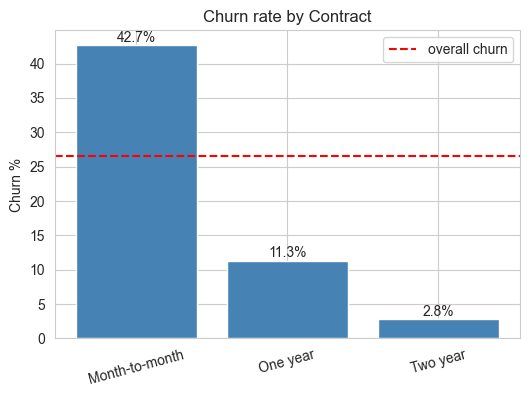

In [209]:
# Hypothesis 1: contract type
print(churn_by('Contract'))
plot_churn('Contract')


              customers  churn_pct
tenure_group                      
0-12               2186       47.4
13-24              1024       28.7
25-48              1594       20.4
49-72              2239        9.5


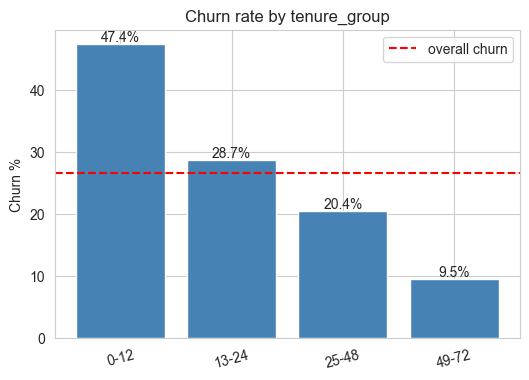

In [210]:
# Hypothesis 2: tenure
df1['tenure_group'] = pd.cut(df1['tenure'], bins=[-1, 12, 24, 48, 72],
                            labels=['0-12', '13-24', '25-48', '49-72'])
print(churn_by('tenure_group'))
plot_churn('tenure_group')

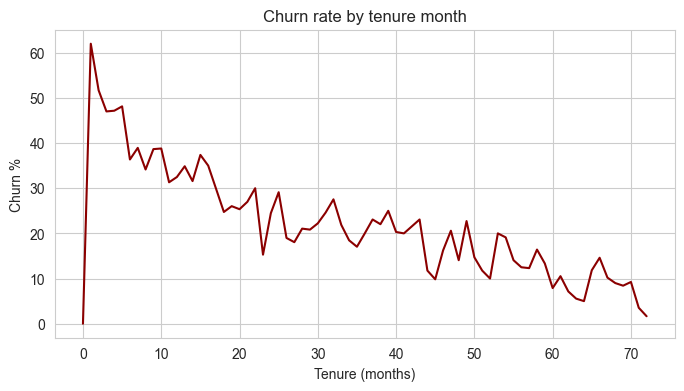

In [211]:
# churn rate for every tenure month
curve = df1.groupby('tenure')['ChurnFlage'].mean() * 100
plt.figure(figsize=(8, 4))
plt.plot(curve.index, curve.values, color='darkred')
plt.title('Churn rate by tenure month')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn %')
plt.savefig('images/tenure_curve.png', bbox_inches='tight')
plt.show()


             customers  churn_pct
TechSupport                      
No                4999       31.2
Yes               2044       15.2 

                customers  churn_pct
OnlineSecurity                      
No                   5024       31.3
Yes                  2019       14.6 

              customers  churn_pct
OnlineBackup                      
No                 4614       29.2
Yes                2429       21.5 

                  customers  churn_pct
DeviceProtection                      
No                     4621       28.7
Yes                    2422       22.5 



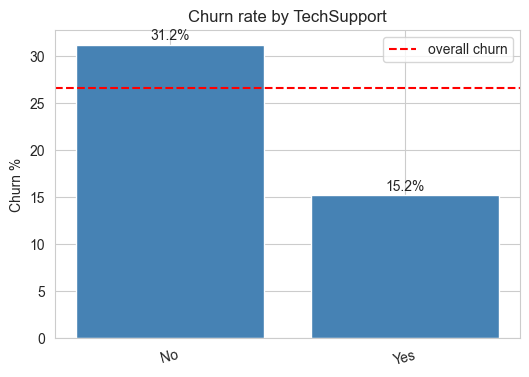

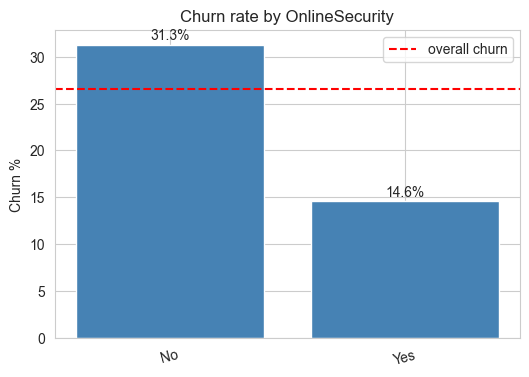

In [212]:
# Hypothesis 3: support services
for col in ['TechSupport', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection']:
    print(churn_by(col), '\n')
plot_churn('TechSupport')
plot_churn('OnlineSecurity')


                 customers  churn_pct
InternetService                      
Fiber optic           3096       41.9
DSL                   2421       19.0
No                    1526        7.4


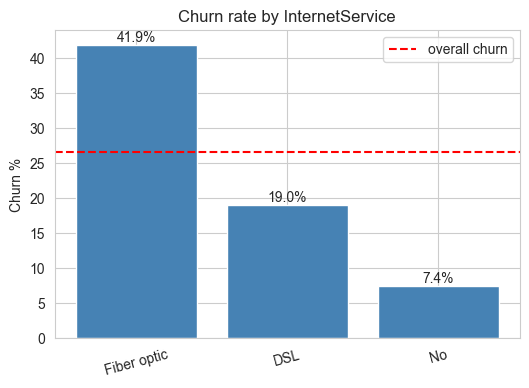

In [213]:
# Hypothesis 4: internet type
print(churn_by('InternetService'))
plot_churn('InternetService')


                  customers  churn_pct
PaymentMethod                         
Electronic check       2365       45.3
Mailed check           1612       19.1
Bank transfer          1544       16.7
Credit card            1522       15.2


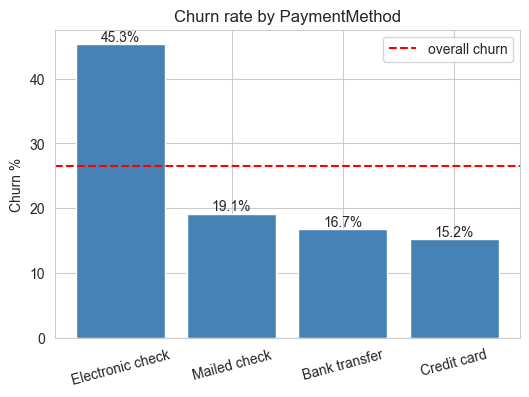

In [214]:
# Hypothesis 5: payment method
print(churn_by('PaymentMethod'))
plot_churn('PaymentMethod')


In [215]:
# other columns
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PaperlessBilling', 'PhoneService', 'MultipleLines',
            'StreamingTV', 'StreamingMovies']:
    print(churn_by(col), '\n')


        customers  churn_pct
gender                      
Female       3488       26.9
Male         3555       26.2 

               customers  churn_pct
SeniorCitizen                      
Yes                 1142       41.7
No                  5901       23.6 

         customers  churn_pct
Partner                      
No            3641       33.0
Yes           3402       19.7 

            customers  churn_pct
Dependents                      
No               4933       31.3
Yes              2110       15.5 

                  customers  churn_pct
PaperlessBilling                      
Yes                    4171       33.6
No                     2872       16.3 

              customers  churn_pct
PhoneService                      
Yes                6361       26.7
No                  682       24.9 

               customers  churn_pct
MultipleLines                      
Yes                 2971       28.6
No                  4072       25.0 

             customers  churn_pct


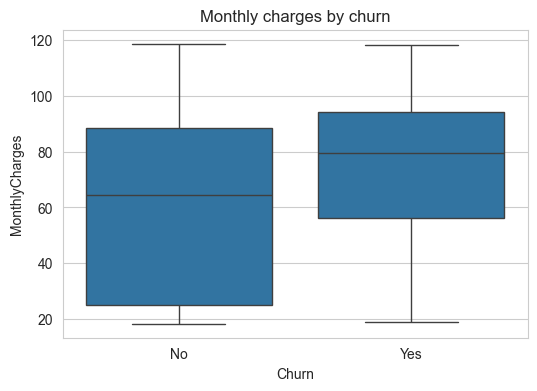

In [216]:
# monthly charges: churned vs retained
plt.figure(figsize=(6, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df1)
plt.title('Monthly charges by churn')
plt.savefig('images/monthly_charges_box.png', bbox_inches='tight')
plt.show()


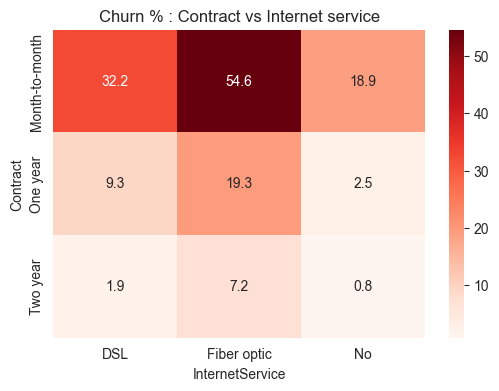

In [217]:
# contract x internet service heatmap (churn %)
pivot = df1.pivot_table(values='ChurnFlage', index='Contract',
                       columns='InternetService', aggfunc='mean') * 100
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn % : Contract vs Internet service')
plt.savefig('images/heatmap_contract_internet.png', bbox_inches='tight')
plt.show()


Contract
Month-to-month    120847.0
One year           14118.0
Two year            4165.0
Name: MonthlyCharges, dtype: float64


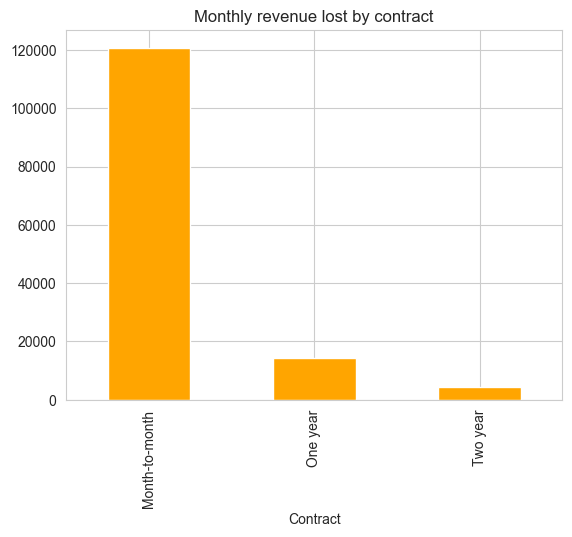

In [218]:
# revenue view: which contract loses the most money
rev = df1[df1['ChurnFlage'] == 1].groupby('Contract')['MonthlyCharges'].sum().round(0)
print(rev)
rev.plot(kind='bar', color='orange', title='Monthly revenue lost by contract')
plt.savefig('images/revenue_lost_contract.png', bbox_inches='tight')
plt.show()



# ## Step 6: Statistical tests (to prove the patterns are real)


In [219]:

# chi-square for categorical columns
# cramers v tells how strong the relation is (0 = none, 1 = perfect)


In [220]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']
 


In [221]:
rows = []
for col in cat_cols:
    table = pd.crosstab(df1[col], df1['Churn'])
    chi2, p, dof, exp = stats.chi2_contingency(table)
    n = table.values.sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    rows.append([col, round(chi2, 1), p, round(v, 3)])
 
chi_result = pd.DataFrame(rows, columns=['column', 'chi2', 'p_value', 'cramers_v'])
chi_result['significant'] = chi_result['p_value'] < 0.05
chi_result.sort_values('cramers_v', ascending=False)


,column,chi2,p_value,cramers_v,significant
13,Contract,1184.6,5.863038e-258,0.410,True
6,InternetService,732.3,9.571788e-160,0.322,True
15,PaymentMethod,648.1,3.682355e-140,0.303,True
14,PaperlessBilling,258.3,4.073355e-58,0.191,True
7,OnlineSecurity,205.6,1.232098e-46,0.171,True
10,TechSupport,190.2,2.923567e-43,0.164,True
3,Dependents,189.1,4.924922e-43,0.164,True
1,SeniorCitizen,159.4,1.510067e-36,0.150,True
2,Partner,158.7,2.139911e-36,0.150,True
8,OnlineBackup,47.3,6.214093e-12,0.082,True


In [222]:
# numeric columns: mann-whitney test (data is not normal so no t-test)
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    a = df1[df1['Churn'] == 'Yes'][col]
    b = df1[df1['Churn'] == 'No'][col]
    stat, p = stats.mannwhitneyu(a, b)
    print(col, '| churned median:', a.median(), '| retained median:', b.median(), '| p-value:', p)


tenure | churned median: 10.0 | retained median: 38.0 | p-value: 2.419635517951866e-208
MonthlyCharges | churned median: 79.65 | retained median: 64.42500000000001 | p-value: 3.311627651988584e-54
TotalCharges | churned median: 703.55 | retained median: 1679.525 | p-value: 5.685033866207314e-83



# ## Step 7: High risk segment


In [223]:
mask = ((df1['Contract'] == 'Month-to-month') &
        (df1['InternetService'] == 'Fiber optic') &
        (df1['tenure'] <= 12) &
        (df1['TechSupport'] == 'No'))


In [224]:
seg = df1[mask]
seg_size_pct = len(seg) / len(df1) * 100
seg_churn_rate = seg['ChurnFlage'].mean() * 100
share_of_churn = seg['ChurnFlage'].sum() / df1['ChurnFlage'].sum() * 100
seg_revenue = seg.loc[seg['ChurnFlage'] == 1, 'MonthlyCharges'].sum()
 


In [225]:
print('Segment customers        :', len(seg))
print('Segment size             : %.1f %% of all customers' % seg_size_pct)
print('Segment churn rate       : %.1f %%  (overall %.1f %%)' % (seg_churn_rate, churn_rate))
print('Share of all churn       : %.1f %%' % share_of_churn)
print('Monthly revenue lost here: %.0f' % seg_revenue)


Segment customers        : 833
Segment size             : 11.8 % of all customers
Segment churn rate       : 71.1 %  (overall 26.5 %)
Share of all churn       : 31.7 %
Monthly revenue lost here: 48490


# ## Step 8: SQL queries (same KPIs from a database)

In [226]:
conn = sqlite3.connect('data/processed/telco.db')
df1.drop(columns=['tenure_group']).to_sql('customers', conn, if_exists='replace', index=False)
 
def run_sql(q):
    return pd.read_sql(q, conn)


In [227]:
# overall numbers
run_sql("""
SELECT COUNT(*) AS customers,
       ROUND(100.0 * SUM(ChurnFlage) / COUNT(*), 2) AS churn_pct,
       ROUND(SUM(CASE WHEN ChurnFlage = 1 THEN MonthlyCharges END), 0) AS monthly_revenue_lost
FROM customers
""")


,customers,churn_pct,monthly_revenue_lost
0,7043,26.54,139131.0


In [228]:
# churn by contract
run_sql("""
SELECT Contract,
       COUNT(*) AS customers,
       ROUND(100.0 * SUM(ChurnFlage) / COUNT(*), 1) AS churn_pct
FROM customers
GROUP BY Contract
ORDER BY churn_pct DESC
""")


,Contract,customers,churn_pct
0,Month-to-month,3875,42.7
1,One year,1473,11.3
2,Two year,1695,2.8


In [229]:
# churn by tenure band using CASE
run_sql("""
SELECT CASE WHEN tenure <= 12 THEN '0-12'
            WHEN tenure <= 24 THEN '13-24'
            WHEN tenure <= 48 THEN '25-48'
            ELSE '49-72' END AS tenure_band,
       COUNT(*) AS customers,
       ROUND(100.0 * SUM(ChurnFlage) / COUNT(*), 1) AS churn_pct
FROM customers
GROUP BY tenure_band
ORDER BY churn_pct DESC
""")


,tenure_band,customers,churn_pct
0,0-12,2186,47.4
1,13-24,1024,28.7
2,25-48,1594,20.4
3,49-72,2239,9.5


In [230]:
# CTE + window function: rank payment methods by churn
run_sql("""
WITH pay AS (
    SELECT PaymentMethod,
           COUNT(*) AS customers,
           100.0 * SUM(ChurnFlage) / COUNT(*) AS churn_pct
    FROM customers
    GROUP BY PaymentMethod
)
SELECT PaymentMethod, customers, ROUND(churn_pct, 1) AS churn_pct,
       RANK() OVER (ORDER BY churn_pct DESC) AS risk_rank
FROM pay
""")


,PaymentMethod,customers,churn_pct,risk_rank
0,Electronic check,2365,45.3,1
1,Mailed check,1612,19.1,2
2,Bank transfer,1544,16.7,3
3,Credit card,1522,15.2,4


In [231]:
# running total of revenue lost by tenure
run_sql("""
WITH lost AS (
    SELECT tenure, SUM(MonthlyCharges) AS revenue_lost
    FROM customers
    WHERE ChurnFlage = 1
    GROUP BY tenure
)
SELECT tenure,
       ROUND(revenue_lost, 0) AS revenue_lost,
       ROUND(SUM(revenue_lost) OVER (ORDER BY tenure), 0) AS running_total
FROM lost
LIMIT 15
""")


,tenure,revenue_lost,running_total
0,1,22115.0,22115.0
1,2,8109.0,30224.0
2,3,6205.0,36429.0
3,4,5863.0,42291.0
4,5,4561.0,46853.0
5,6,3043.0,49896.0
6,7,3834.0,53730.0
7,8,3183.0,56913.0
8,9,3234.0,60147.0
9,10,3607.0,63754.0


In [232]:
# same high risk segment in SQL
run_sql("""
SELECT COUNT(*) AS customers,
       ROUND(100.0 * SUM(ChurnFlage) / COUNT(*), 1) AS churn_pct
FROM customers
WHERE Contract = 'Month-to-month'
  AND InternetService = 'Fiber optic'
  AND tenure <= 12
  AND TechSupport = 'No'
""")
 


,customers,churn_pct
0,833,71.1


In [233]:
conn.close()


# ## Step 9: Feature engineering

In [234]:
def make_features(data):
    d = data.copy()
 
    # how many extra services the customer uses
    d['num_services'] = (d[service_cols] == 'Yes').sum(axis=1)
    protect_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
    d['num_protection'] = (d[protect_cols] == 'Yes').sum(axis=1)
 
    # tenure based
    d['tenure_group'] = pd.cut(d['tenure'], bins=[-1, 12, 24, 48, 72],
                               labels=['0-12', '13-24', '25-48', '49-72']).astype(str)
    d['is_new_customer'] = (d['tenure'] <= 6).astype(int)
 
    # billing based
    d['avg_monthly_spend'] = np.where(d['tenure'] > 0, d['TotalCharges'] / d['tenure'],
                                      d['MonthlyCharges'])
    d['charge_diff'] = d['MonthlyCharges'] - d['avg_monthly_spend']
    d['charge_per_service'] = d['MonthlyCharges'] / (d['num_services'] + 1)
    d['is_autopay'] = d['PaymentMethod'].str.contains('automatic|Bank|Credit', case=False).astype(int)
 
    # family
    d['family_status'] = (d['Partner'] == 'Yes').astype(int) + (d['Dependents'] == 'Yes').astype(int)
 
    # risky combinations
    d['monthly_fiber'] = ((d['Contract'] == 'Month-to-month') &
                          (d['InternetService'] == 'Fiber optic')).astype(int)
    d['monthly_echeck'] = ((d['Contract'] == 'Month-to-month') &
                           (d['PaymentMethod'] == 'Electronic check')).astype(int)
    d['fiber_no_support'] = ((d['InternetService'] == 'Fiber optic') &
                             (d['TechSupport'] == 'No')).astype(int)
    return d


In [235]:
data = make_features(df1.drop(columns=['tenure_group']))
data[['num_services', 'num_protection', 'is_new_customer', 'avg_monthly_spend',
      'charge_diff', 'is_autopay', 'monthly_fiber']].head()
 


,num_services,num_protection,is_new_customer,avg_monthly_spend,charge_diff,is_autopay,monthly_fiber
0,1,1,1,29.850000,0.000000,0,0
1,2,2,0,55.573529,1.376471,0,0
2,2,2,1,54.075000,-0.225000,0,0
3,3,3,0,40.905556,1.394444,1,0
4,0,0,1,75.825000,-5.125000,0,1


In [236]:
# do the new features have any link with churn?
data.groupby('num_services')['ChurnFlage'].mean().round(3)


num_services
0    0.214
1    0.458
2    0.358
3    0.274
4    0.223
5    0.124
6    0.053
Name: ChurnFlage, dtype: float64

# ## Step 10: Train test split and pipeline



In [237]:
# Split first, then fit scaler/encoder only on train data (avoids data leakage)
X = data.drop(columns=['customerID', 'Churn', 'ChurnFlage'])
y = data['ChurnFlage']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
 
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Churn rate train: %.3f  test: %.3f' % (y_train.mean(), y_test.mean()))
 


Train: (5634, 31)  Test: (1409, 31)
Churn rate train: 0.265  test: 0.265


In [238]:
def make_preprocessor(columns):
    num = [c for c in columns if pd.api.types.is_numeric_dtype(X[c])]
    cat = [c for c in columns if c not in num]
    return ColumnTransformer([
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
    ])
 
all_cols = list(X.columns)


# ## Step 11: Models

In [239]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                            class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
fitted = {}


In [240]:
for name, model in models.items():
    pipe = Pipeline([('prep', make_preprocessor(all_cols)), ('model', model)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    report = classification_report(y_test, pred, output_dict=True)
    results.append({
        'model': name,
        'cv_auc': round(cv_auc, 3),
        'test_auc': round(roc_auc_score(y_test, prob), 3),
        'pr_auc': round(average_precision_score(y_test, prob), 3),
        'precision': round(report['1']['precision'], 3),
        'recall': round(report['1']['recall'], 3),
        'f1': round(report['1']['f1-score'], 3)
    })
    fitted[name] = pipe


In [241]:
results_df = pd.DataFrame(results)
results_df


,model,cv_auc,test_auc,pr_auc,precision,recall,f1
0,Logistic Regression,0.847,0.844,0.652,0.505,0.797,0.618
1,Random Forest,0.846,0.845,0.653,0.544,0.775,0.639
2,Gradient Boosting,0.844,0.843,0.656,0.657,0.521,0.581


In [242]:
# did feature engineering help? same model on original columns only
original_cols = [c for c in df.columns if c not in ['customerID', 'Churn', 'ChurnFlag', 'tenure_group']]
base_pipe = Pipeline([
    ('prep', make_preprocessor(original_cols)),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
base_pipe.fit(X_train[original_cols], y_train)
base_auc = roc_auc_score(y_test, base_pipe.predict_proba(X_test[original_cols])[:, 1])
new_auc = results_df.loc[results_df['model'] == 'Logistic Regression', 'test_auc'].values[0]
print('Original columns AUC     :', round(base_auc, 3))
print('With engineered features :', new_auc)


Original columns AUC     : 0.842
With engineered features : 0.844


In [243]:
# pick the best model by test auc
best_name = results_df.sort_values('test_auc', ascending=False).iloc[0]['model']
best_model = fitted[best_name]
print('Best model:', best_name)


Best model: Random Forest


In [244]:
prob = best_model.predict_proba(X_test)[:, 1]

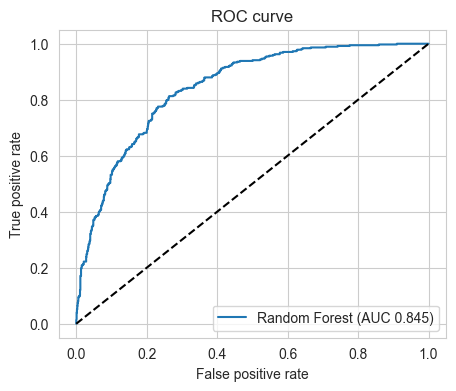

In [245]:
# roc curve
fpr, tpr, _ = roc_curve(y_test, prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=best_name + ' (AUC %.3f)' % roc_auc_score(y_test, prob))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.title('ROC curve')
plt.savefig('images/roc_curve.png', bbox_inches='tight')
plt.show()


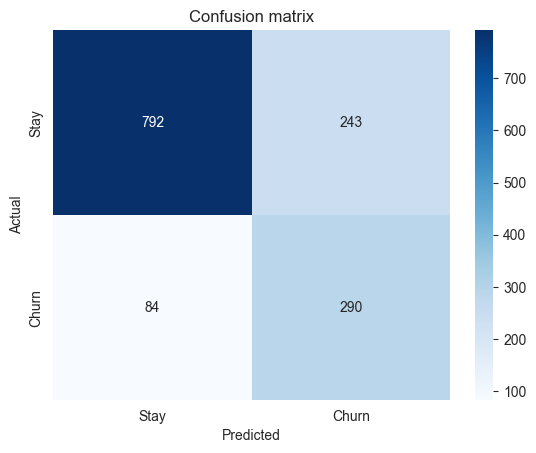

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



In [246]:
# confusion matrix at 0.5
pred = (prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.savefig('images/confusion_matrix.png', bbox_inches='tight')
plt.show()
print(classification_report(y_test, pred))


# ## Step 12: What drives churn? (permutation importance)

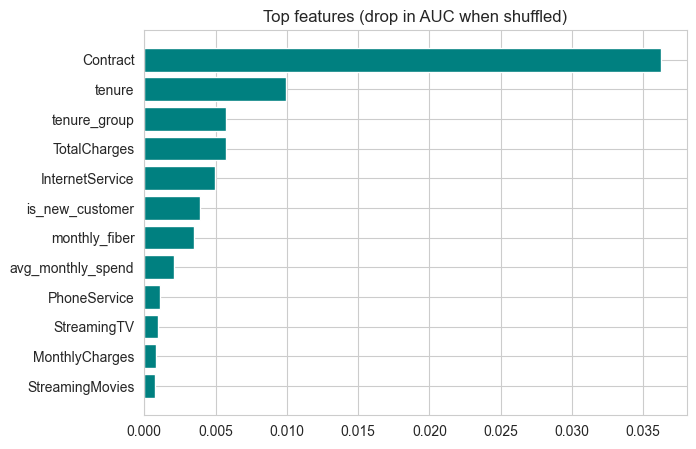

,feature,importance
14,Contract,0.036240
4,tenure,0.009919
21,tenure_group,0.005756
18,TotalCharges,0.005707
7,InternetService,0.004955
22,is_new_customer,0.003944
28,monthly_fiber,0.003485
23,avg_monthly_spend,0.002098
5,PhoneService,0.001114
12,StreamingTV,0.000963


In [247]:
imp = permutation_importance(best_model, X_test, y_test, scoring='roc_auc',
                             n_repeats=5, random_state=42)
imp_df = pd.DataFrame({'feature': X_test.columns, 'importance': imp.importances_mean})
imp_df = imp_df.sort_values('importance', ascending=False).head(12)
 
plt.figure(figsize=(7, 5))
plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='teal')
plt.title('Top features (drop in AUC when shuffled)')
plt.savefig('images/feature_importance.png', bbox_inches='tight')
plt.show()
imp_df


# ## Step 13: Business impact - choosing the threshold with money
# These numbers are assumptions, change them and write them in your report.
# Keep offer cost in the same currency as MonthlyCharges.


    threshold  contacted  churners_caught  net_benefit
0        0.10       1109              370        64083
1        0.15       1008              364        64704
2        0.20        921              357        64812
3        0.25        828              350        65040
4        0.30        768              341        64141
5        0.35        682              322        61432
6        0.40        617              311        60167
7        0.45        570              299        58309
8        0.50        533              290        56951
9        0.55        482              269        53075
10       0.60        419              244        48507
11       0.65        369              226        45310
12       0.70        290              190        38497
13       0.75        220              150        30571
14       0.80        148              109        22452
15       0.85         85               71        14853
16       0.90         41               35         7340

Best thre

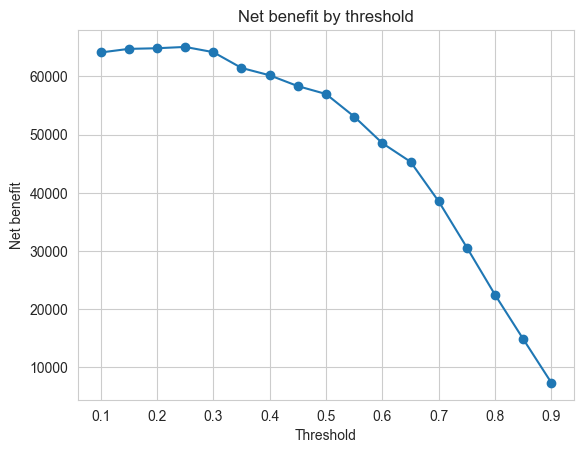

In [248]:
offer_cost = 20           # cost of one retention offer (dataset charges are in dollars)
success_rate = 0.30       # 30% of contacted churners will stay
avg_customer_value = df['MonthlyCharges'].mean() * 12   # one year value
 
rows = []
for t in np.arange(0.10, 0.91, 0.05):
    contacted = prob >= t
    n_contacted = contacted.sum()
    true_churners = (contacted & (y_test.values == 1)).sum()
    saved_value = true_churners * success_rate * avg_customer_value
    cost = n_contacted * offer_cost
    rows.append([round(t, 2), n_contacted, true_churners, round(saved_value - cost)])
 
thr = pd.DataFrame(rows, columns=['threshold', 'contacted', 'churners_caught', 'net_benefit'])
best_row = thr.loc[thr['net_benefit'].idxmax()]
print(thr)
print('\nBest threshold:', best_row['threshold'], '| net benefit:', best_row['net_benefit'])
 
plt.plot(thr['threshold'], thr['net_benefit'], marker='o')
plt.title('Net benefit by threshold')
plt.xlabel('Threshold')
plt.ylabel('Net benefit')
plt.savefig('images/threshold_benefit.png', bbox_inches='tight')
plt.show()
 


    threshold  contacted  churners_caught  net_benefit
0        0.10       1109              370        64083
1        0.15       1008              364        64704
2        0.20        921              357        64812
3        0.25        828              350        65040
4        0.30        768              341        64141
5        0.35        682              322        61432
6        0.40        617              311        60167
7        0.45        570              299        58309
8        0.50        533              290        56951
9        0.55        482              269        53075
10       0.60        419              244        48507
11       0.65        369              226        45310
12       0.70        290              190        38497
13       0.75        220              150        30571
14       0.80        148              109        22452
15       0.85         85               71        14853
16       0.90         41               35         7340

Best thre

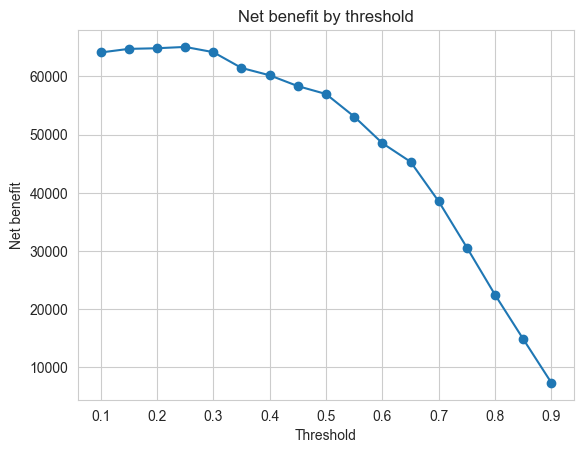

In [249]:
offer_cost = 20           # cost of one retention offer (dataset charges are in dollars)
success_rate = 0.30       # 30% of contacted churners will stay
avg_customer_value = df['MonthlyCharges'].mean() * 12   # one year value
 
rows = []
for t in np.arange(0.10, 0.91, 0.05):
    contacted = prob >= t
    n_contacted = contacted.sum()
    true_churners = (contacted & (y_test.values == 1)).sum()
    saved_value = true_churners * success_rate * avg_customer_value
    cost = n_contacted * offer_cost
    rows.append([round(t, 2), n_contacted, true_churners, round(saved_value - cost)])
 
thr = pd.DataFrame(rows, columns=['threshold', 'contacted', 'churners_caught', 'net_benefit'])
best_row = thr.loc[thr['net_benefit'].idxmax()]
print(thr)
print('\nBest threshold:', best_row['threshold'], '| net benefit:', best_row['net_benefit'])
 
plt.plot(thr['threshold'], thr['net_benefit'], marker='o')
plt.title('Net benefit by threshold')
plt.xlabel('Threshold')
plt.ylabel('Net benefit')
plt.savefig('images/threshold_benefit.png', bbox_inches='tight')
plt.show()
 


Top 10% customers -> 28.1% of churners caught
Top 20% customers -> 50.0% of churners caught
Top 30% customers -> 66.0% of churners caught
Top 40% customers -> 79.7% of churners caught


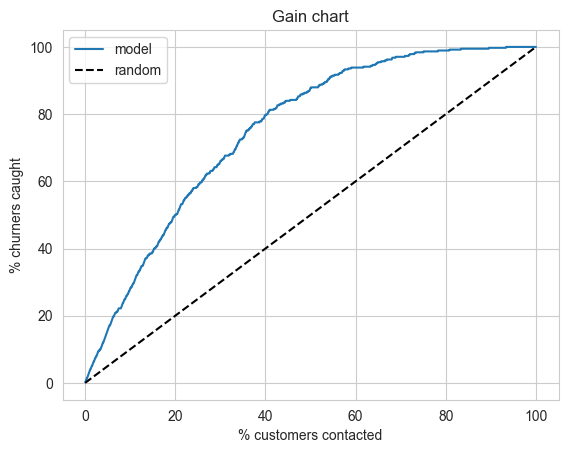

In [250]:
# gain table: if we call top 20% risky customers, how many churners do we catch?
test_result = pd.DataFrame({'prob': prob, 'actual': y_test.values}).sort_values('prob', ascending=False)
test_result['cum_churn'] = test_result['actual'].cumsum()
test_result['pct_customers'] = np.arange(1, len(test_result) + 1) / len(test_result) * 100
test_result['pct_churn_caught'] = test_result['cum_churn'] / test_result['actual'].sum() * 100
 
for p in [10, 20, 30, 40]:
    row = test_result[test_result['pct_customers'] >= p].iloc[0]
    print('Top %d%% customers -> %.1f%% of churners caught' % (p, row['pct_churn_caught']))
 
plt.plot(test_result['pct_customers'], test_result['pct_churn_caught'], label='model')
plt.plot([0, 100], [0, 100], 'k--', label='random')
plt.xlabel('% customers contacted')
plt.ylabel('% churners caught')
plt.title('Gain chart')
plt.legend()
plt.savefig('images/gain_chart.png', bbox_inches='tight')
plt.show()


# ## Step 14: Save model and risk list

In [251]:
joblib.dump(best_model, 'models/churn_model.pkl')
 
risk_list = X_test.copy()
risk_list['customerID'] = data.loc[X_test.index, 'customerID']
risk_list['churn_probability'] = prob.round(3)
risk_list['actual_churn'] = y_test.values
risk_list = risk_list.sort_values('churn_probability', ascending=False)
risk_list[['customerID', 'Contract', 'InternetService', 'tenure',
           'MonthlyCharges', 'churn_probability', 'actual_churn']].to_csv(
    'reports/high_risk_customers.csv', index=False)
 
risk_list[['customerID', 'Contract', 'tenure', 'MonthlyCharges', 'churn_probability']].head(10)


,customerID,Contract,tenure,MonthlyCharges,churn_probability
6866,0295-PPHDO,Month-to-month,1,95.45,0.951
3380,5178-LMXOP,Month-to-month,1,95.10,0.945
4585,1069-XAIEM,Month-to-month,1,85.05,0.944
1731,8375-DKEBR,Month-to-month,1,69.60,0.935
809,1820-TQVEV,Month-to-month,1,69.55,0.934
2927,5542-TBBWB,Month-to-month,1,69.90,0.933
3727,9057-SIHCH,Month-to-month,3,96.60,0.933
1739,9804-ICWBG,Month-to-month,1,69.90,0.933
2753,6857-VWJDT,Month-to-month,1,95.65,0.930
2194,2514-GINMM,Month-to-month,1,79.50,0.929


# ## Step 15: Final summary

In [252]:
print('Overall churn rate      : %.1f %%' % churn_rate)
print('Yearly revenue lost     : %.0f' % yearly_loss)
print('High risk segment       : %.1f %% of customers, %.1f %% of churn, churn rate %.1f %%'
      % (seg_size_pct, share_of_churn, seg_churn_rate))
print('Best model              :', best_name)
print(results_df[results_df['model'] == best_name].to_string(index=False))
 


Overall churn rate      : 26.5 %
Yearly revenue lost     : 1669570
High risk segment       : 11.8 % of customers, 31.7 % of churn, churn rate 71.1 %
Best model              : Random Forest
        model  cv_auc  test_auc  pr_auc  precision  recall    f1
Random Forest   0.846     0.845   0.653      0.544   0.775 0.639


# Final Insights

## 1. Business Impact
- Of 7,043 customers, **1,869 churned (26.54%)**. The retention rate is 73.46%.
- **Monthly revenue lost is 139,131, which is 30.5% of total monthly revenue** (about 1.67M per year).
- The revenue loss (30.5%) is higher than the customer loss (26.5%) because customers who churned paid more (average 74.4 vs 61.3 per month).
- Churned customers had an average tenure of 18 months vs 37.6 for retained customers (median 10 vs 38). Their average lifetime value was 1,339 vs 2,305.

## 2. Top Churn Drivers (ranked by Cramér's V)
| Rank | Factor | Cramér's V | Insight |
|---|---|---|---|
| 1 | Contract | 0.41 | Month-to-month 42.7%, one-year 11.3%, two-year 2.8% |
| 2 | Internet Service | 0.32 | Fiber optic 41.9%, DSL 19.0%, no internet 7.4% |
| 3 | Payment Method | 0.30 | Electronic check 45.3%, other methods 15-19% |
| 4 | Paperless Billing | 0.19 | Paperless 33.6% vs 16.3% |
| 5 | Online Security / Tech Support | 0.17 / 0.16 | About 31% churn without them, about 15% with them |

All factors are statistically significant (p < 0.05) except gender (p = 0.49) and phone service (p = 0.34).

## 3. Contract and Revenue
- **About 87% of lost revenue (120,847 of 139,131) comes from month-to-month customers.**
- One-year contracts lost 14,118 and two-year contracts lost only 4,165.

## 4. Tenure (The First Year)
- Churn is **47.4%** in months 0-12, 28.7% in months 13-24, 20.4% in months 25-48 and only 9.5% after 49 months.
- **Month 1 alone loses 22,115 in monthly revenue (about 16% of the total).** The first 12 months account for about 50% of all lost revenue.
- This points to an onboarding and early-experience problem.

## 5. Services
- **Tech support:** 31.2% churn without it vs 15.2% with it.
- **Online security:** 31.3% churn without it vs 14.6% with it.
- Online backup (29.2% vs 21.5%) and device protection (28.7% vs 22.5%) have a smaller effect.
- Streaming TV and movies customers churn slightly more (about 30% vs 24%), but the effect is small (V ≈ 0.06). It is probably linked to fiber and higher prices.
- Customers with more services tend to churn less. Note that the "0 services" group includes customers with no internet, who rarely churn, so it should be read separately.

## 6. Customer Profile
- **Senior citizens churn at 41.7%** vs 23.6% for non-seniors.
- **Customers without a partner churn at 33.0%** (19.7% with a partner). **Customers without dependents churn at 31.3%** (15.5% with dependents).
- **Gender has no significant effect on churn.**

## 7. Price
- Churned customers had a median monthly charge of 79.65 vs 64.43 for retained customers (p < 0.001). Higher-paying customers are more likely to leave.

## 8. High-Risk Segment
Month-to-month contract + fiber optic + tenure of 12 months or less + no tech support:
- **833 customers (11.8% of the base)**
- **71.1% churn rate**, about 2.7x the overall rate of 26.5%
- **31.7% of all churn**, and 48,490 of monthly revenue lost (about 35% of the total loss)
- This is the first group to target with retention offers.

## 9. Predictive Model
- All three models perform almost identically on the test set: Logistic Regression 0.844, Random Forest 0.845, Gradient Boosting 0.843 ROC-AUC (cross-validated AUC about 0.85).
- Random Forest **caught 78% of churners (recall)** with 54% precision at the default 0.5 cutoff.
- Feature engineering moved AUC only from 0.842 to 0.844, so most of the signal was already in the original features.
- **Contract is the most important feature (0.036), followed by tenure (0.010).** Electronic check and tech support do not appear in the model's top features because they overlap with contract and tenure.
- **The top 20% of customers ranked by risk contain 50% of all churners (2.5x lift)**, and the top 40% contain 79.7%.

## 10. Recommendations
1. **Offer annual-contract discounts to month-to-month customers.** They are the source of about 87% of lost revenue.
2. **Give new fiber customers free tech support or online security in their first year.**
3. **Run an onboarding campaign for the first 3 months**